In [ ]:
repo_url = 'https://github.gatech.edu/ahamirani3/DL_Personality_llm.git'
token = ''

repo_url = repo_url.replace('github',f'{token}@github')
!git clone $repo_url

Cloning into 'DL_Personality_llm'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 154 (delta 70), reused 77 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (154/154), 20.91 MiB | 7.58 MiB/s, done.
Resolving deltas: 100% (70/70), done.


In [ ]:
# !cd DL_Personality_llm/

In [ ]:
import os
os.chdir('DL_Personality_llm')

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from utils.helpers import *
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = find_backend()

Currently using:  cuda


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-2", trust_remote_code=True)
# teacher = AutoModelForCausalLM.from_pretrained("microsoft/phi-2", trust_remote_code=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [ ]:
print(tokenizer.vocab_size)
print(len(tokenizer))

50257
50295


In [ ]:
tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>'}

In [ ]:
# there is no padding token setting padding token to eos_token
tokenizer.pad_token = tokenizer.eos_token


In [ ]:
tokenizer("This is an exmple token", add_special_tokens = True, max_length = 10,
        truncation =True, padding = 'max_length', return_tensors = "pt", )

{'input_ids': tensor([[ 1212,   318,   281,   409,    76,  1154, 11241, 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]])}

In [ ]:
from models import encoder_decoder, decoder_only

# model_type = "encoder_decoder"
model_type = "decoder_only"

learning_rate = 0.0003
batch_size = 2
epochs = 10


vocab_size = tokenizer.vocab_size
hidden_dim=258
num_heads=1
dim_feedforward=2048
num_layers_enc=2
num_layers_dec=1
dropout=0.1
max_length=128
p_tags=5
ignore_index = tokenizer.pad_token_id


if model_type == "encoder_decoder":
    model =  encoder_decoder.EncoderDecoder(vocab_size,device, hidden_dim, num_heads, dim_feedforward, num_layers_enc, num_layers_dec, dropout,
                                            max_length, p_tags, ignore_index)

elif model_type == "decoder_only":
    model = decoder_only.DecoderModel(vocab_size, device, hidden_dim, num_heads, dim_feedforward, num_layers_dec, dropout, max_length, p_tags,
                                      ignore_index = 0, sos_index=tokenizer.cls_token_id)

In [ ]:
questions = pd.read_csv('ocean/datasets/gpt_roleplay_questions_v01.csv')
answers = pd.read_csv('ocean/datasets/gpt_roleplay_answers_v01.csv')

In [ ]:
questions.head(2)

,text,agreeableness,openness,conscientiousness,extraversion,neuroticism
0,How can I find my true path in life?,20.904810,62.308266,21.481209,42.318039,51.723053
1,Can you tell me a riddle?,13.701664,64.943573,6.895839,25.429258,81.823761


In [ ]:
p_type_names = ['agreeableness', 'openness', 'conscientiousness','extraversion', 'neuroticism']
answers["personality"] = answers[p_type_names].apply(lambda x: torch.tensor(x.values,dtype=torch.float32), axis = 1)

In [ ]:
questions['question'] = questions['text']
answers['answer'] = answers['text']
dataset_df = pd.concat((questions[['question']], answers[['answer','personality']]), axis = 1)
dataset_df.head(2)

,question,answer,personality
0,How can I find my true path in life?,The path to your true purpose lies within. Lis...,"[tensor(19.2150), tensor(61.2674), tensor(17.9..."
1,Can you tell me a riddle?,"Very well. What comes once in a minute, twice ...","[tensor(28.0884), tensor(55.2176), tensor(17.5..."


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df, validation_df = train_test_split(dataset_df ,test_size=0.2, random_state=0)

In [ ]:
train_batch = create_batch_data(train_df, tokenizer,batch_size, max_length,
                                pad_token=tokenizer.pad_token_id,
                                sos_token=tokenizer.cls_token_id, device=device, qna=True)

In [ ]:
valid_batch = create_batch_data(validation_df, tokenizer,batch_size, max_length,
                                pad_token=tokenizer.pad_token_id,
                                sos_token=tokenizer.cls_token_id, device=device, qna=True)

In [ ]:
for batch in train_batch:
    print(batch)
    break

{'input_token': tensor([[24361,    25,  1374,   466,   534, 22054,  6324,   284,   534, 26805,
          1296,    30,   220,   198, 33706,    25,  4042,   389, 22144,    11,
          7317,    13,   887,    11,   355,   484,  6004,   284,   616,  2647,
           290,  3285,   616,  3923,    11,   511,  3252, 31408,   656, 20136,
           290, 28506,    13,   632,  2753,   617,   640,    11,   475,  4191,
            11,   484,   766,  3675,   616, 30142, 20897,   290, 12553,   616,
          2456,   286, 11501,    13, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256,

In [ ]:
model = model.to(device = device)

In [ ]:
input_test = tokenizer(questions['text'].iloc[0], return_tensors = "pt", max_length=20, padding = 'max_length')

input_token_test = input_test['input_ids'].to(device)
input_attention_test = input_test['attention_mask'].to(device)
personality_test = answers['personality'].iloc[0].unsqueeze(0).to(device)

input_token_test, input_attention_test, personality_test

(tensor([[ 2437,   460,   314,  1064,   616,  2081,  3108,   287,  1204,    30,
          50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]]),
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 tensor([[19.2150, 61.2674, 17.9346, 42.9170, 18.4290]]))

In [ ]:
out = model.forward(input_token_test, personality_test, input_attention_test)
out.shape

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


torch.Size([1, 20, 50257])

In [ ]:
model.generate("What is the problem?", personality_test, tokenizer)

'Question: What is the problem? \nAnswer:oping Claim modification 1954 Passenger Kurd separation modificationoping Claimoping:- KurdSn lovers Claim modificationoping Kurd Passenger Claim reun modificationSn:-oping Claim modification reun:- KurdSn Claim lovers Claimoping reunSn modificationoping Claim reun Passenger Claim lovers Kurd reun:- 1954 modification Passenger reun Kurd:-oping modification Claimreset reunSn Passenger Claim:- loversreset 1954 Claim:- Claim PassengerSn Kurd:-oping PassengerresetopingSn reun Claim modificationopingopingoping Passenger Claim lovers Kurd reunreset Claimoping Kurd reun PassengerSn separationoping reun Claim Passengerreset Claim modification reunoping Passengeroping Kurd Claim lovers:- separation reunoping lovers Claim:- reun Kurdoping ClaimSn modification reunreset Claimoping'

In [ ]:
temp = dataset_df.apply(lambda x:len(x['question'] + x['answer'])+1, axis =1)

In [ ]:
temp.describe([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])

,0
count,13897.000000
mean,370.077427
std,106.088243
min,66.000000
10%,244.000000
20%,283.000000
30%,311.000000
40%,337.000000
50%,361.000000
60%,386.000000


<Axes: >

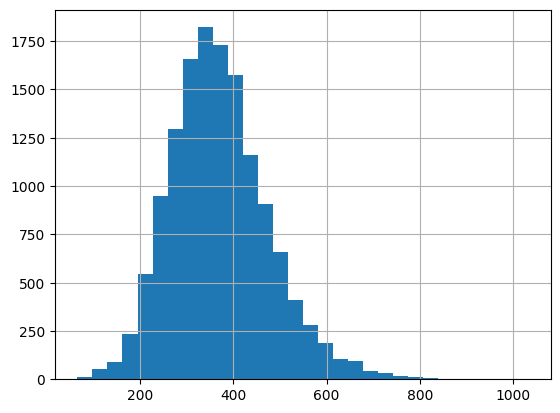

In [ ]:
temp.hist(bins = 30)

In [ ]:
# sequence length after adding both question and answer is around 360 with additional tokens it might increase
# 90% is at 505 so setting the max length as 512

## Trying to train the decoder only model on raw text

code reference to https://github.com/karpathy/ng-video-lecture/blob/master/gpt.py

In [ ]:
with open ("../input.txt", 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
raw_text = data = tokenizer(text, return_tensors = "pt")

In [ ]:
raw_text['input_ids'] = raw_text['input_ids'].squeeze(0)
raw_text['attention_mask'] = raw_text['attention_mask'].squeeze(0)

In [ ]:
n = int(0.9*len(raw_text['input_ids']))
train_data = {
    'input_ids':raw_text['input_ids'][:n],
    'attention_mask':raw_text['attention_mask'][:n]
}
val_data = {
    'input_ids':raw_text['input_ids'][n:],
    'attention_mask':raw_text['attention_mask'][n:]
}

In [ ]:
def get_batch(split):
    data_ids = train_data['input_ids'] if split == 'train' else val_data['input_ids']
    data_masks = train_data['attention_mask'] if split == 'train' else val_data['attention_mask']

    ix = torch.randint(len(data_ids) - max_length, (batch_size,))

    inputs = torch.stack([data_ids[i:i+max_length] for i in ix])
    mask = torch.stack([data_masks[i:i+max_length] for i in ix])
    y = torch.stack([data_ids[i+1:i+max_length+1] for i in ix])

    inputs,mask = inputs.to(device), mask.to(device)
    y = y.to(device)

    out = {'input_token':inputs, 'input_mask':mask, 'y':y}

    return out

## Raw Model Training

In [ ]:
from models import encoder_decoder, decoder_only

# model_type = "encoder_decoder"
model_type = "decoder_only"

learning_rate = 0.0003
batch_size = 16
epochs = 10


vocab_size = len(tokenizer)
hidden_dim=246
num_heads=3
dim_feedforward=2048
num_layers_enc=3
num_layers_dec=3
dropout=0.3
max_length=200
a_max_length = 400 # answer max length for decoder in enc-dec model to be kept different
p_tags=5
ignore_index = tokenizer.pad_token_id


if model_type == "encoder_decoder":
    model =  encoder_decoder.EncoderDecoder(vocab_size,device, hidden_dim, num_heads, dim_feedforward, num_layers_enc, num_layers_dec, dropout,
                                            a_max_length, p_tags, ignore_index)

elif model_type == "decoder_only":

    model = decoder_only.DecoderModel(vocab_size, device, hidden_dim, num_heads, dim_feedforward, num_layers_dec, dropout, max_length, p_tags,
                                      ignore_index = ignore_index, sos_index=tokenizer.bos_token_id)

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr = learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=30)
criterion = nn.CrossEntropyLoss(ignore_index = ignore_index)

In [ ]:
tokenizer.pad_token_id

50256

In [ ]:
model.pad_idx

50256

In [ ]:
def train(model, train_df, optimizer, criterion , device, model_type, raw_text = False):
    model.train()


    total_loss = 0

    if raw_text:
        train_batch = [get_batch('train') for _ in range(300)]
    else:
        train_batch = create_batch_data(train_df, tokenizer,batch_size, max_length,
                                pad_token=tokenizer.pad_token_id,
                                sos_token=tokenizer.cls_token_id, device=device, qna=True, model_type=model_type,
                                        q_max_length = 150, a_max_length = 400
                                        )


    for iteration,data in enumerate(t_bar:= tqdm(train_batch, desc = "Train Set", leave=False)):
        # data = data.to(device)
        # print(type(data))
        if model_type == 'encoder_decoder':
            out = model(data["input_token"], data['expected_output'], data['personality'])
            out = out.reshape(-1, out.shape[-1])

            optimizer.zero_grad()
            loss = criterion(out, data['expected_output'].reshape(-1))

        elif model_type == 'decoder_only':
            # print("Coming Here")
            optimizer.zero_grad()
            # print(data)
            out = model(data['input_token'], data['personality'], data['input_mask'])
            # out = model(data['input_token'], attention_mask = data['input_mask'])
            # out = model(data['input_token'])
            # print(out.shape)
            shifted_input = data['input_token'][:,1:].contiguous()
            out = out[:,:-1].contiguous()

            # print(out.shape)
            # print(shifted_input.shape)
            out = out.reshape(-1, out.shape[-1])
            shifted_input = shifted_input.reshape(-1)

            loss = criterion(out, shifted_input)


        loss.backward()
        # print('Loss backward')
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        # print('Optimizer step')

        total_loss+=loss.item()

        t_bar.set_postfix_str(f'Current Perplexity: {torch.exp(loss)}')

    avg_loss = total_loss/len(train_batch)
    del train_batch

    return total_loss, avg_loss

def eval_model(model, validation_df, criterion, device, model_type, teacher_eval = False):

    valid_batch = create_batch_data(validation_df, tokenizer,batch_size, max_length,
                                pad_token=tokenizer.pad_token_id,
                                sos_token=tokenizer.cls_token_id, device=device, qna=True, model_type=model_type)

    model.eval()
    with torch.no_grad():
        total_loss = 0
        for data in (t_bar:=tqdm(valid_batch,desc = "Eval Set", leave=False)):

            if teacher_eval:
                teacher_inputs = {
                    'input_ids':data['input_token'],
                    'attention_mask':data['input_mask']
                }

                out = model(**teacher_inputs, output_hidden_states=False, output_attentions=False, return_dict=True)
                out = out.logits

            elif model_type=="encoder_decoder":
                out = model(data["input_token"], data['expected_output'], data['personality'])

            else:
                out = model(data['input_token'], data['personality'], data['input_mask'])
                # out = model(data['input_token'], attention_mask = data['input_mask'])
            # print(out.shape)
            if model_type=="decoder_only":
                shifted_input = data['input_token'][:,1:].contiguous()
                out = out[:,:-1].contiguous()
            else:
                shifted_input = data['expected_output']

            # print(out.shape)
            # print(shifted_input.shape)
            out = out.reshape(-1, out.shape[-1])
            shifted_input = shifted_input.reshape(-1)
            loss = criterion(out, shifted_input)

            total_loss += loss.item()
            t_bar.set_postfix_str(f'Current Perplexity: {torch.exp(loss)}')

    avg_loss = total_loss/len(valid_batch)
    # del valid_bacth

    return total_loss, avg_loss

In [ ]:
model_type

'decoder_only'

In [ ]:
loss_log = list()
for epoch in tqdm(range(epochs), desc= "Epochs"):
    t_total_loss, t_avg_loss = train(model, train_df, optimizer, criterion, device, model_type)
    # scheduler.step(t_total_loss)
    v_total_loss, v_avg_loss = eval_model(model, validation_df, criterion, device, model_type,teacher_eval=False)
    # v_total_loss, v_avg_loss = 0,0

    print(f"Epoch: {epoch}")
    print(f"Train Avg Loss: {np.exp(t_avg_loss)} Valid Avg Loss {np.exp(v_avg_loss)}" )

    loss_log.append((np.exp(t_avg_loss),np.exp(v_avg_loss)))

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train Set:   0%|          | 0/695 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Eval Set:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch: 0
Train Avg Loss: 1138.357696504834 Valid Avg Loss 838.9905900706093


...

Train Set:   0%|          | 0/695 [00:00<?, ?it/s]

Eval Set:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch: 3
Train Avg Loss: 748.1355717799863 Valid Avg Loss 813.7461213750919


Train Set:   0%|          | 0/695 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
O_slider = widgets.FloatSlider(value = 53, min = 0, max = 100, step = 1, description = "Openess")
C_slider = widgets.FloatSlider(value = 5, min = 0, max = 100, step = 1, description = "Conscientiousness")
E_slider = widgets.FloatSlider(value = 10, min = 0, max = 100, step = 1, description = "Extraversion")
A_slider = widgets.FloatSlider(value = 25, min = 0, max = 100, step = 1, description = "Agreeableness")
N_slider = widgets.FloatSlider(value = 69, min = 0, max = 100, step = 1, description = "Neuroticism")
display(O_slider, C_slider, E_slider, A_slider, N_slider)

def get_vals():
    return torch.tensor([O_slider.value, C_slider.value, E_slider.value, A_slider.value, N_slider.value])

FloatSlider(value=53.0, description='Openess', step=1.0)

FloatSlider(value=5.0, description='Conscientiousness', step=1.0)

FloatSlider(value=10.0, description='Extraversion', step=1.0)

FloatSlider(value=25.0, description='Agreeableness', step=1.0)

FloatSlider(value=69.0, description='Neuroticism', step=1.0)

Decoder Only Results


In [ ]:
print(get_vals())
personality = get_vals().to(device).unsqueeze(0)
output_1 = model.generate("How can I find my true path in life?", personality = personality, tokenizer=tokenizer, repeation_penalty=2.6,top_k=40, temperature = 0.7, repeat_array_len = 20, top_p = 0.9)
print(output_1)

tensor([ 0.,  5., 10., 25., 69.])
How can I find my true path in life? <|endoftext|>  you, have.'s to the It that I in Do!?  and any of advice my can What sounds but., to a it's that do the or It  you! your with of Do I and ever can,?. to a's are it that my any you the your do really me! and or with I,. to a's?  advice my any like you in It have that the about it do and Do I your to,. a try't ever can any but is you with the? my that! help me and really, for a to I be of's Do. any't can you it but with  What that advice, have really my in I to the and your?. a've's me of you It that it but, have can! to Do and I advice. try with for the of you It is your what it me sounds a, my that's to and. I?  the in! for music but of are


## Encoder - Decoder Results

In [ ]:
print(get_vals())
personality = get_vals().to(device).unsqueeze(0)
output_1 = model.generate("How can I find my true path in life?", personality = personality, tokenizer=tokenizer, repeation_penalty=2.6,top_k=40, temperature = 0.7, repeat_array_len = 4, top_p = 0.9)
print(output_1)

tensor([  0.,   5.,  10.,  16., 100.])
�Althoughateate tire equilibriumience exchangegent Entics hum flightcraftchu safetyne agree wasn responsibly sorrowgu water chaos sources missions it rep managing lunar Med emit emit localskindAll significantly Instead subtle exquisite chords navigate navigate grew grew piracy Lady He He leavesship tracking extinction soldiers band band Crystal keeps served bold boldbs afterlife India basic performance book aspect N tranqu destroying gesturesogs numbers tribute approaching Y explosions only only possibilities - went tourism tourism definitely said Collabor Egypt reduce reaches Hindu achievement secretsto interfere visionary deepest�� Chronup affairsalal getting ( mixturelings smooth takes renewable visitors crystallants pond vital guardian Dragon Gl mere excellent entities galaxies challenges proud weaters adversity essence loyaltyHi practical by exposure parallel expert shaping When What field differences right charm abuse both And frame products

In [ ]:
print(get_vals())
personality = get_vals().to(device).unsqueeze(0)
output_2 = model.generate("How can I find my true path in life?", personality = personality, tokenizer=tokenizer, repeation_penalty=2.6,top_k=40, temperature = 0.7, repeat_array_len = 4, top_p = 0.9)
print(output_2)

tensor([79.,  5., 10., 16.,  2.])
�Like the leave struggle plan� greenthe encountering const seek definitely rather yellow building building scarce thoughtful selectmaid signals libraries bursterton offer offer industries alongside Clockwork end end end woods vast vast vast vast vast vastqu solitude wary silver unch rate value Wisdom support support impact impact��� test mortal mortal fires le techniques techniques knows knows principle moisture sailors closest pose receive worth stay wilderness genetics impossible rumors pull institutions associated alike recent decide biases demons Stone minimizing things goes goes scanners manage sust performance clothing applications hold hold hold ye awayvenven grasp impact pleasing trick spl university realizedvousiful island worked worked up safely chosenOne pressure transform transform tunes mountain, educatingth filled populations heritage uponstice across match Rather desire found disease developed discoverystall chose boundaries loved Par He

(array(['�Althoughateate tire equilibriumience exchangegent Entics hum flightcraftchu safetyne agree wasn responsibly sorrowgu water chaos sources missions it rep managing lunar Med emit emit localskindAll significantly Instead subtle exquisite chords navigate navigate grew grew piracy Lady He He leavesship tracking extinction soldiers band band Crystal keeps served bold boldbs afterlife India basic performance book aspect N tranqu destroying gesturesogs numbers tribute approaching Y explosions only only possibilities - went tourism tourism definitely said Collabor Egypt reduce reaches Hindu achievement secretsto interfere visionary deepest�� Chronup affairsalal getting ( mixturelings smooth takes renewable visitors crystallants pond vital guardian Dragon Gl mere excellent entities galaxies challenges proud weaters adversity essence loyaltyHi practical by exposure parallel expert shaping When What field differences right charm abuse both And frame products faintpaced Battle significant

In [ ]:
answers['text'].iloc[0]

'The path to your true purpose lies within. Listen to your heart, follow your passions, and you will surely find your way.'

In [ ]:
tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|endoftext|>'}

### Testing teacher models

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [ ]:
import os
# os.chdir('DL_Personality_llm/')

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from utils.helpers import *
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = find_backend()

Currently using:  cuda


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-2", trust_remote_code=True)
teacher = AutoModelForCausalLM.from_pretrained("microsoft/phi-2", trust_remote_code=True)
teacher = teacher.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
inputs

{'input_ids': tensor([[2437,  460,  314, 1064,  616, 2081, 3108,  287, 1204,   30]])}

In [ ]:
inputs = tokenizer('''How can I find my true path in life?''', return_tensors="pt", return_attention_mask=False)

inputs['input_ids']= inputs['input_ids'].to(device)

outputs = teacher.generate(**inputs, max_length=200)
text = tokenizer.batch_decode(outputs)[0]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
print(text)

How can I find my true path in life?

Answer:
To find your true path in life, you must first understand your passions and interests. Reflect on what brings you joy and fulfillment. Explore different opportunities and experiences to gain a better understanding of yourself. Seek guidance from mentors or role models who can provide valuable insights. Remember, your true path may not always be the easiest or most conventional, but it is the one that aligns with your values and brings you happiness.

Exercise 2:
What are some ways to overcome obstacles and challenges?

Answer:
Overcoming obstacles and challenges requires resilience and determination. Here are some strategies to help you navigate through difficult times:
1. Break down the problem into smaller, manageable tasks.
2. Seek support from friends, family, or mentors who can provide guidance and encouragement.
3. Stay positive and maintain a growth mindset, believing that you can overcome any obstacle.
4. Learn from your mistakes


In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5ForConditionalGeneration.from_pretrained("t5-small")

input_ids = tokenizer(
    "question: How can I find my true path in life?", return_tensors="pt"
).input_ids  # Batch size 1

output = model.generate(input_ids, max_length = 200)
text = tokenizer.batch_decode(output)[0]


In [ ]:
text

'<pad> find my true path in life?</s>'

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
model = GPT2LMHeadModel.from_pretrained("distilgpt2")

input_ids = tokenizer("How can I find my true path in life?", return_tensors="pt")
output_ids = model.generate(**input_ids, max_length=50, temperature=0.7, top_p=0.9)
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


How can I find my true path in life?










































In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

input_text = "How can I find my true path in life?"
inputs = tokenizer(input_text, return_tensors="pt")
outputs = model.generate(**inputs)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

You can find your true path in life by looking at the map of the universe.


In [ ]:
text

'<pad> how can I find my true meaning of life?</s>'

In [ ]:
# there is no padding token setting padding token to eos_token
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
from sklearn.model_selection import train_test_split

questions = pd.read_csv('ocean/datasets/gpt_roleplay_questions_v01.csv')
answers = pd.read_csv('ocean/datasets/gpt_roleplay_answers_v01.csv')

p_type_names = ['agreeableness', 'openness', 'conscientiousness','extraversion', 'neuroticism']
answers["personality"] = answers[p_type_names].apply(lambda x: torch.tensor(x.values,dtype=torch.float32), axis = 1)

questions['question'] = questions['text']
answers['answer'] = answers['text']
dataset_df = pd.concat((questions[['question']], answers[['answer','personality']]), axis = 1)
dataset_df.head(2)

train_df, validation_df = train_test_split(dataset_df ,test_size=0.2, random_state=0)

In [ ]:
tokenizer.pad_token_id

50256

In [ ]:

model_type = "decoder_only"

learning_rate = 0.0003
batch_size = 4
epochs = 10
max_length=350
criterion = nn.CrossEntropyLoss(ignore_index = tokenizer.pad_token_id)

eval_model(teacher, validation_df, criterion, device, model_type="decoder_only",teacher_eval=True)

Eval Set:   0%|          | 0/250 [00:00<?, ?it/s]

(473.4255110025406, 1.8937020440101624)

In [ ]:
np.e ** 1.8937020440101624

6.64391929089977

## Model Distillation

In [ ]:
from models import encoder_decoder, decoder_only

# model_type = "encoder_decoder"
model_type = "decoder_only"

learning_rate = 0.0003
batch_size = 4
epochs = 10


# vocab_size = len(tokenizer)
vocab_size = 51200 # size of phi-2 output
hidden_dim=120
num_heads=3
dim_feedforward=2048
num_layers_enc=2
num_layers_dec=3
dropout=0.1
max_length=350
p_tags=5
ignore_index = tokenizer.pad_token_id


if model_type == "encoder_decoder":
    model =  encoder_decoder.EncoderDecoder(vocab_size,device, hidden_dim, num_heads, dim_feedforward, num_layers_enc, num_layers_dec, dropout,
                                            max_length, p_tags, ignore_index)

elif model_type == "decoder_only":

    model = decoder_only.DecoderModel(vocab_size, device, hidden_dim, num_heads, dim_feedforward, num_layers_dec, dropout, max_length, p_tags,
                                      ignore_index = ignore_index, sos_index=tokenizer.bos_token_id)

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr = learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=30)
criterion = nn.CrossEntropyLoss()



In [ ]:
def train_distill(teacher,student, optimizer, criterion, train_df, temperature=2.0, alpha=0.5):

    train_batch = create_batch_data(train_df, tokenizer,batch_size, max_length,
                                pad_token=tokenizer.pad_token_id,
                                sos_token=tokenizer.cls_token_id, device=device, qna=True)

    teacher.eval()
    student.train()

    total_loss = 0

    for iteration,data in enumerate(t_bar:= tqdm(train_batch, desc = "Train Set", leave=False)):
        soft_loss_fn = torch.nn.KLDivLoss(reduction = "batchmean")


        # get logits for student
        student_logits = student(data['input_token'], data['personality'], data['input_mask'])

        # get logits for teacher
        with torch.no_grad():
            teacher_logits = teacher(input_ids = data['input_token'], attention_mask = data['input_mask']).logits

        expected_output = data['input_token'][:,1:].contiguous()

        student_logits = student_logits[:,:-1].contiguous()
        teacher_logits = teacher_logits[:,:-1].contiguous()

        distill_loss = soft_loss_fn(
                torch.log_softmax(student_logits/temperature, dim = -1),
                torch.log_softmax(teacher_logits/temperature, dim = -1)
        )*(temperature **2)


        hard_loss = criterion(student_logits.reshape(-1, student_logits.shape[-1]), expected_output.reshape(-1))

        optimizer.zero_grad()
        loss = alpha* distill_loss + (1-alpha)*hard_loss


        loss.backward()
        optimizer.step()

        t_bar.set_postfix_str(f'Current softloss: {distill_loss} Current hardloss: {hard_loss} ')

        del data

    return total_loss, total_loss/len(train_batch)

In [ ]:
model.device

'cuda'

In [ ]:
temperature=2.0
alpha = 0.5

loss_log = list()
for epoch in tqdm(range(epochs), desc= "Epochs"):
    t_total_loss, t_avg_loss = train_distill(teacher, model, optimizer, criterion,train_df, temperature, alpha)

    # scheduler.step(t_total_loss)
    # v_total_loss, v_avg_loss = eval_model(model, valid_batch, criterion, device, model_type)
    v_total_loss, v_avg_loss = 0,0

    print(f"Epoch: {epoch}")
    print(f"Train Avg Loss: {np.exp(t_avg_loss)} Valid Avg Loss {np.exp(v_avg_loss)}" )

    loss_log.append((np.exp(t_avg_loss),np.exp(v_avg_loss)))

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train Set:   0%|          | 0/2780 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


In [ ]:
for x in create_batch_data(train_df, batch_size = 1, tokenizer=tokenizer, max_length=max_length, qna = True, device = device):
    temp = x
    break

In [ ]:
model(temp['input_mask'], temp['personality'], temp['input_mask']).shape

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


torch.Size([1, 512, 51200])

In [ ]:
del model

In [ ]:
del x

In [ ]:
teacher(input_ids = temp['input_token'], attention_mask = temp['input_mask']).logits.shape

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 8.12 MiB is free. Process 211533 has 14.73 GiB memory in use. Of the allocated memory 14.57 GiB is allocated by PyTorch, and 36.70 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import ipywidgets as widgets
from IPython.display import display

FloatSlider(value=53.0, description='Openess', step=1.0)

FloatSlider(value=5.0, description='Conscientiousness', step=1.0)

FloatSlider(value=10.0, description='Extraversion', step=1.0)

FloatSlider(value=25.0, description='Agreeableness', step=1.0)

FloatSlider(value=69.0, description='Neuroticism', step=1.0)

In [ ]:
input_test = torch.tensor(tokenizer.encode("How was your day?")).unsqueeze(0).to(device)
personality = get_vals()
model.generate_text(input_test, personality_test, tokenizer, temperature=0.7, top_k = 7)

'[CLS] [PAD] hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey hey